# 05 — Évaluation de la robustesse

**Mini-projet IA Responsable — Phase 4 / 5**

On évalue la résilience des trois modèles entraînés (baseline, fair_weighted, fair_multitask) face à deux familles de perturbations :

| Famille | Mécanisme | Intensité |
|---|---|---|
| **Bruit caractère** (`noise`) | `char_typo_noise` (suppression/substitution stochastique), `random_case` (casse aléatoire), `remove_whitespace` (suppression espaces) | p ∈ {0.05, 0.10} pour typo ; p = 0.20 pour casse |
| **Attaque sémantique** (`adversarial`) | TextFooler (TextAttack) — substitutions de synonymes guidées par les gradients du modèle, contraintes par cosine USE | recette `TextFoolerJin2019` standard |

**Métriques** :
- Bruit : ΔAUC, ΔECE, **flip-rate** (fraction de prédictions binaires modifiées par la perturbation).
- Adversariale : **ASR** (Attack Success Rate), nombre moyen de mots modifiés, % requêtes au modèle.

**Question scientifique** : la mitigation équité de la P2 (fair-A, fair-B) **transfère-t-elle** ses gains à la robustesse adversariale, ou un compromis apparaît-il ?

---

**Sommaire**

0. Setup & configuration
1. Rechargement test + sample TextFooler
2. Fonctions de bruit + helpers
3. Définition du modèle multi-tâches (reload P2-B)
4. Pipeline bruit caractère × 3 modèles
5. Visualisations bruit (ΔAUC, ΔECE, flip-rate)
6. Attaque TextFooler × 3 modèles
7. Tableau récapitulatif final
8. Sauvegarde + diagnostic


## 0. Setup & configuration


In [1]:
import gc
import json
import os
import random
import string
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from sklearn.metrics import roc_auc_score

os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("USE_TORCH", "1")

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertModel,
    BertPreTrainedModel,
)
from transformers.modeling_outputs import ModelOutput

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

# TextAttack import (gracefully optional)
try:
    import textattack
    from textattack.models.wrappers import ModelWrapper
    from textattack.attack_recipes import TextFoolerJin2019
    from textattack.datasets import Dataset as TADataset
    HAS_TEXTATTACK = True
    print(f"textattack : {textattack.__version__}")
except Exception as e:
    HAS_TEXTATTACK = False
    print(f"[warn] textattack indisponible ({e}). La section adversariale sera sautée.")


Device : cuda
[warn] textattack indisponible (module 'textattack' has no attribute '__version__'). La section adversariale sera sautée.


In [5]:
# === Chemins ===
DATA_DIR = Path(
    os.environ.get("JIGSAW_DATA_DIR",
                   "../data/")
).expanduser().resolve()
TRAIN_CSV = DATA_DIR / "train.csv"

REPORTS_DIR = Path("../reports").resolve()
SPLITS_DIR  = REPORTS_DIR / "splits"
METRICS_DIR = REPORTS_DIR / "metrics"
FIGURES_DIR = REPORTS_DIR / "figures"
ROBUST_DIR  = REPORTS_DIR / "robustness"
for p in (METRICS_DIR, FIGURES_DIR, ROBUST_DIR):
    p.mkdir(parents=True, exist_ok=True)

MODELS = {
    "baseline":       REPORTS_DIR / "checkpoints" / "baseline_bert",
    "fair_weighted":  REPORTS_DIR / "checkpoints" / "fair_weighted",
    "fair_multitask": REPORTS_DIR / "checkpoints" / "fair_multitask",
}
for name, path in MODELS.items():
    print(f"  {name:<14s} {path}   exists={path.exists()}")

# === Hyperparamètres ===
SEED       = 1337
MAX_LEN    = 128
BATCH_SIZE = 64

# Sous-échantillonnage du test pour accélérer l'inférence bruit (None = tout)
N_TEST_NOISE = 10_000

# TextFooler : nombre de commentaires toxiques à attaquer
N_ATTACK     = 100        # 100 par modèle = ~10-20 min sur RTX 4080
ATTACK_HIGH_CONFIDENCE = 0.80   # seuil pour sélectionner les "bien classés"

# Bruits
NOISE_RECIPES = [
    ("typo_p05",       {"kind": "typo",       "p": 0.05}),
    ("typo_p10",       {"kind": "typo",       "p": 0.10}),
    ("random_case",    {"kind": "case",       "p": 0.20}),
    ("remove_spaces",  {"kind": "ws",         "p": None}),
]

# Reproductibilité
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def free_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


  baseline       C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\baseline_bert   exists=True
  fair_weighted  C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_weighted   exists=True
  fair_multitask C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_multitask   exists=True


## 1. Rechargement test + sample TextFooler

On rejoue les splits P1, charge le test set. Pour TextFooler, on **sélectionne uniquement les commentaires toxiques bien classés** par chaque modèle individuellement (P(toxic) ≥ 0.80) — c'est sur ceux-là que l'attaque a un sens (faire basculer une bonne prédiction).


In [6]:
IDENTITY_COLS = [
    "asian", "atheist", "bisexual", "black", "buddhist", "christian", "female",
    "heterosexual", "hindu", "homosexual_gay_or_lesbian",
    "intellectual_or_learning_disability", "jewish", "latino", "male", "muslim",
    "other_disability", "other_gender", "other_race_or_ethnicity", "other_religion",
    "other_sexual_orientation", "physical_disability", "psychiatric_or_mental_illness",
    "transgender", "white",
]
N_ID = len(IDENTITY_COLS)
LABEL_THRESHOLD    = 0.5
IDENTITY_THRESHOLD = 0.5
MIN_TEST_PER_IDENTITY = 500


In [7]:
assert TRAIN_CSV.exists(), f"Fichier introuvable: {TRAIN_CSV}"
splits_path = SPLITS_DIR / "split_ids.json"
assert splits_path.exists(), f"Splits introuvables: {splits_path}"

with open(splits_path, encoding="utf-8") as f:
    splits = json.load(f)
print(f"Splits : test = {len(splits['test']):,}")

USE_COLS = ["id", "comment_text", "target"] + IDENTITY_COLS
test_ids = set(splits["test"])
df_full = pd.read_csv(TRAIN_CSV, usecols=USE_COLS)
test_df = df_full[df_full["id"].isin(test_ids)].set_index("id").loc[splits["test"]].reset_index()
del df_full; gc.collect()

test_df["label"] = (test_df["target"].fillna(0) >= LABEL_THRESHOLD).astype(int)
for c in IDENTITY_COLS:
    test_df[c + "_bin"] = (test_df[c].fillna(0) >= IDENTITY_THRESHOLD).astype(int)
test_df["any_identity"] = test_df[[c + "_bin" for c in IDENTITY_COLS]].max(axis=1)
print(f"Test : {len(test_df):,} lignes | toxic_rate = {test_df['label'].mean():.4f}")

# Sous-échantillonnage pour bruit (préserve la stratification)
if N_TEST_NOISE is not None and N_TEST_NOISE < len(test_df):
    test_noise_df = test_df.groupby(["label", "any_identity"], group_keys=False).apply(
        lambda g: g.sample(
            n=int(round(N_TEST_NOISE * len(g) / len(test_df))),
            random_state=SEED,
        )
    ).reset_index(drop=True)
    print(f"\nÉchantillon bruit : {len(test_noise_df):,} (stratifié)")
else:
    test_noise_df = test_df


Splits : test = 180,491
Test : 180,491 lignes | toxic_rate = 0.0800

Échantillon bruit : 10,001 (stratifié)


## 2. Fonctions de bruit + helpers


In [8]:
def char_typo_noise(text: str, p: float = 0.05, seed: int | None = None) -> str:
    """Suppression ou substitution caractère stochastique."""
    rng = random.Random(seed)
    letters = string.ascii_letters
    out = []
    for ch in text:
        if rng.random() >= p:
            out.append(ch); continue
        if rng.random() < 0.5:
            continue        # suppression
        out.append(rng.choice(letters))    # substitution
    return "".join(out)


def random_case_noise(text: str, p: float = 0.2, seed: int | None = None) -> str:
    """Inversion aléatoire de casse."""
    rng = random.Random(seed)
    out = []
    for ch in text:
        if ch.isalpha() and rng.random() < p:
            out.append(ch.upper() if ch.islower() else ch.lower())
        else:
            out.append(ch)
    return "".join(out)


def remove_whitespace_noise(text: str) -> str:
    return "".join(text.split())


def apply_noise(texts: list[str], kind: str, p: float | None) -> list[str]:
    """Applique un bruit à une liste de textes, avec seed déterministe par exemple."""
    out = []
    for i, t in enumerate(texts):
        seed_i = SEED + i
        if kind == "typo":
            out.append(char_typo_noise(t, p=p, seed=seed_i))
        elif kind == "case":
            out.append(random_case_noise(t, p=p, seed=seed_i))
        elif kind == "ws":
            out.append(remove_whitespace_noise(t))
        else:
            raise ValueError(f"Unknown noise: {kind}")
    return out


In [9]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


@torch.inference_mode()
def predict_proba(model, tokenizer, texts, *, max_length=MAX_LEN, batch_size=BATCH_SIZE, device=DEVICE):
    model.to(device).eval()
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, truncation=True, padding=True,
                        max_length=max_length, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        out = model(**enc)
        z = out.logits.squeeze(-1).detach().cpu().numpy()
        all_probs.append(sigmoid(z))
    return np.concatenate(all_probs, axis=0)


def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)
    conf = np.where(y_pred == 1, y_prob, 1.0 - y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
        if not np.any(mask): continue
        acc = float(np.mean(y_pred[mask] == y_true[mask]))
        avg_conf = float(np.mean(conf[mask]))
        ece += (np.sum(mask) / n) * abs(acc - avg_conf)
    return float(ece)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if y_true.size == 0 or y_true.min() == y_true.max():
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


## 3. Définition du modèle multi-tâches (reload P2-B)


In [10]:
@dataclass
class ToxicityIdentityOutput(ModelOutput):
    loss: Optional[torch.Tensor] = None
    logits: Optional[torch.Tensor] = None
    identity_logits: Optional[torch.Tensor] = None


class BertForToxicityAndIdentity(BertPreTrainedModel):
    def __init__(self, config, num_identities: int = N_ID):
        super().__init__(config)
        self.num_identities = int(num_identities)
        self.bert = BertModel(config, add_pooling_layer=True)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.toxicity_classifier = nn.Linear(config.hidden_size, 1)
        self.identity_classifier = nn.Linear(config.hidden_size, self.num_identities)
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                             token_type_ids=token_type_ids, **kwargs)
        pooled = self.dropout(outputs.pooler_output)
        tox_logits = self.toxicity_classifier(pooled).squeeze(-1)
        id_logits  = self.identity_classifier(pooled)
        return ToxicityIdentityOutput(logits=tox_logits, identity_logits=id_logits)


def load_model(label: str):
    path = MODELS[label]
    if not path.exists():
        return None, None
    if label == "fair_multitask":
        model = BertForToxicityAndIdentity.from_pretrained(str(path), num_identities=N_ID)
    else:
        model = AutoModelForSequenceClassification.from_pretrained(str(path))
    tok = AutoTokenizer.from_pretrained(str(path), use_fast=True)
    return model, tok


## 4. Pipeline bruit caractère × 3 modèles

Pour chaque modèle, on prédit d'abord sur le test **propre** (référence), puis sur chaque variante bruitée. Métriques par perturbation : `AUC`, `ECE`, `flip_rate = mean(1[pred_clean != pred_noisy])`.


In [11]:
texts_clean = test_noise_df["comment_text"].astype(str).tolist()
y_true_n    = test_noise_df["label"].to_numpy()

# Pré-calcul des textes bruités (1 fois pour les 3 modèles)
noisy_texts = {}
for noise_name, cfg in NOISE_RECIPES:
    noisy_texts[noise_name] = apply_noise(texts_clean, cfg["kind"], cfg.get("p"))
    print(f"  bruit {noise_name:<15s} : longueur moyenne {np.mean([len(t) for t in noisy_texts[noise_name]]):.0f}")

noise_results = {}
for label in MODELS:
    print(f"\n=== {label} ===")
    model, tok = load_model(label)
    if model is None:
        print(f"  [skip] checkpoint manquant"); continue

    # Référence
    probs_clean = predict_proba(model, tok, texts_clean)
    pred_clean  = (probs_clean >= 0.5).astype(int)
    auc_clean   = safe_auc(y_true_n, probs_clean)
    ece_clean   = expected_calibration_error(y_true_n, probs_clean)
    print(f"  CLEAN   : AUC = {auc_clean:.4f} | ECE = {ece_clean:.4f}")

    per_noise = {"clean": {"auc": auc_clean, "ece": ece_clean, "flip_rate": 0.0}}
    for noise_name, _ in NOISE_RECIPES:
        probs_n = predict_proba(model, tok, noisy_texts[noise_name])
        pred_n  = (probs_n >= 0.5).astype(int)
        auc_n   = safe_auc(y_true_n, probs_n)
        ece_n   = expected_calibration_error(y_true_n, probs_n)
        flip    = float(np.mean(pred_n != pred_clean))
        per_noise[noise_name] = {
            "auc": auc_n, "ece": ece_n, "flip_rate": flip,
            "delta_auc": auc_n - auc_clean, "delta_ece": ece_n - ece_clean,
        }
        print(f"  {noise_name:<15s} : AUC = {auc_n:.4f} (Δ {auc_n-auc_clean:+.4f}) | "
              f"ECE = {ece_n:.4f} (Δ {ece_n-ece_clean:+.4f}) | flip = {flip:.4f}")

    noise_results[label] = per_noise
    del model, tok; free_cuda()

# Sauvegarde
with open(METRICS_DIR / "robustness_noise.json", "w", encoding="utf-8") as f:
    json.dump(noise_results, f, indent=2, default=float)
print(f"\nÉcrit : {METRICS_DIR / 'robustness_noise.json'}")


  bruit typo_p05        : longueur moyenne 290
  bruit typo_p10        : longueur moyenne 283
  bruit random_case     : longueur moyenne 297
  bruit remove_spaces   : longueur moyenne 245

=== baseline ===
  CLEAN   : AUC = 0.9638 | ECE = 0.0187
  typo_p05        : AUC = 0.8958 (Δ -0.0680) | ECE = 0.0291 (Δ +0.0103) | flip = 0.0314
  typo_p10        : AUC = 0.8174 (Δ -0.1464) | ECE = 0.0416 (Δ +0.0228) | flip = 0.0480
  random_case     : AUC = 0.9638 (Δ +0.0000) | ECE = 0.0187 (Δ +0.0000) | flip = 0.0000
  remove_spaces   : AUC = 0.6590 (Δ -0.3048) | ECE = 0.0627 (Δ +0.0440) | flip = 0.0643

=== fair_weighted ===
  CLEAN   : AUC = 0.9631 | ECE = 0.0193
  typo_p05        : AUC = 0.9001 (Δ -0.0630) | ECE = 0.0295 (Δ +0.0103) | flip = 0.0334
  typo_p10        : AUC = 0.8269 (Δ -0.1361) | ECE = 0.0407 (Δ +0.0214) | flip = 0.0498
  random_case     : AUC = 0.9631 (Δ +0.0000) | ECE = 0.0193 (Δ +0.0000) | flip = 0.0000
  remove_spaces   : AUC = 0.6665 (Δ -0.2966) | ECE = 0.0618 (Δ +0.0425) | f

## 5. Visualisations bruit


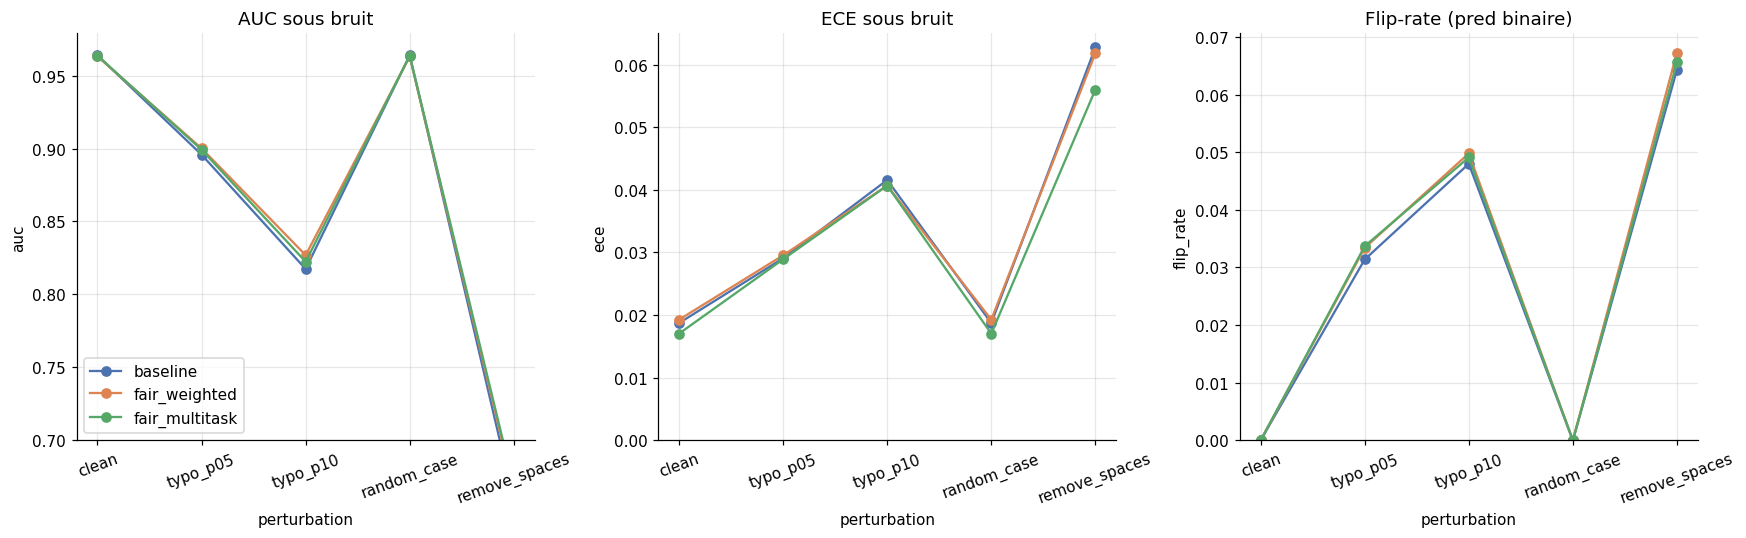

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\robustness_noise.png


In [12]:
COLORS = {"baseline": "#4C72B0", "fair_weighted": "#DD8452", "fair_multitask": "#55A868"}

# Reconstruit un DataFrame "long" : (model × noise × metric)
rows = []
for label, per_noise in noise_results.items():
    for noise_name, m in per_noise.items():
        rows.append({"model": label, "noise": noise_name,
                     "auc": m["auc"], "ece": m["ece"],
                     "flip_rate": m.get("flip_rate", 0.0),
                     "delta_auc": m.get("delta_auc", 0.0),
                     "delta_ece": m.get("delta_ece", 0.0)})
robust_df = pd.DataFrame(rows)

# AUC par bruit
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
order_noise = ["clean"] + [n for n, _ in NOISE_RECIPES]

for ax, metric, title, ymin in [
    (axes[0], "auc",       "AUC sous bruit",       0.7),
    (axes[1], "ece",       "ECE sous bruit",       0.0),
    (axes[2], "flip_rate", "Flip-rate (pred binaire)", 0.0),
]:
    sub = robust_df.copy()
    sub["noise"] = pd.Categorical(sub["noise"], categories=order_noise, ordered=True)
    sub = sub.sort_values("noise")
    for label in noise_results:
        sub_l = sub[sub["model"] == label]
        ax.plot(sub_l["noise"], sub_l[metric], marker="o",
                color=COLORS[label], label=label, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("perturbation")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(ymin, None)
    ax.tick_params(axis="x", rotation=20)
axes[0].legend(loc="lower left")
plt.tight_layout()
fig_path = FIGURES_DIR / "robustness_noise.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure : {fig_path}")


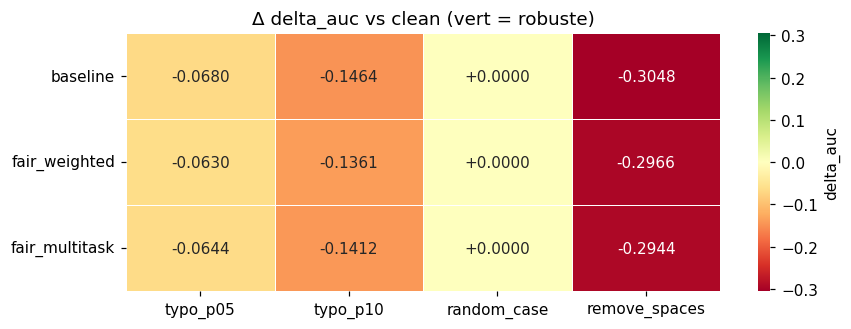

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\robustness_delta_auc_heatmap.png


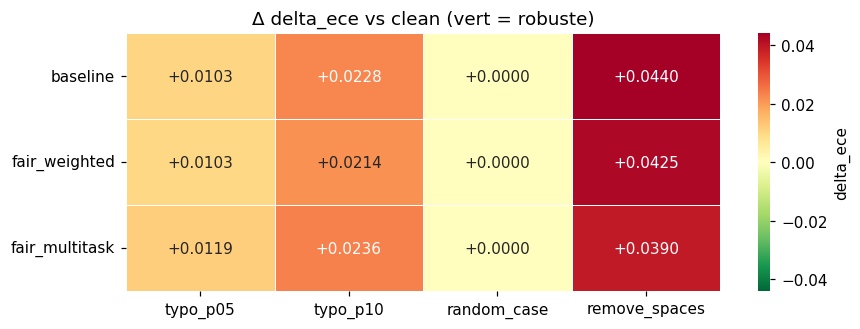

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\robustness_delta_ece_heatmap.png


In [13]:
# Heatmap Δ vs clean (par modèle × perturbation)
def heatmap_delta(metric: str, fname: str, fmt: str = "+.4f", cmap: str = "RdYlGn_r"):
    pivot = robust_df.pivot(index="model", columns="noise", values=metric)
    pivot = pivot.drop(columns=["clean"], errors="ignore")
    pivot = pivot.reindex([l for l in noise_results.keys() if l in pivot.index])
    pivot = pivot[[n for n, _ in NOISE_RECIPES if n in pivot.columns]]
    if pivot.empty:
        return
    vmax = float(np.nanmax(np.abs(pivot.values))) or 0.01
    fig, ax = plt.subplots(figsize=(2.5 + 1.4 * len(pivot.columns), 1 + 0.7 * len(pivot)))
    sns.heatmap(pivot, annot=True, fmt=fmt,
                cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
                ax=ax, linewidths=0.4, cbar_kws={"label": metric})
    ax.set_title(f"Δ {metric} vs clean (vert = robuste)")
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, bbox_inches="tight")
    plt.show()
    print(f"Figure : {FIGURES_DIR / fname}")


heatmap_delta("delta_auc", "robustness_delta_auc_heatmap.png", cmap="RdYlGn")
heatmap_delta("delta_ece", "robustness_delta_ece_heatmap.png", cmap="RdYlGn_r")


## 6. Attaque TextFooler × 3 modèles

[**TextFooler**](https://arxiv.org/abs/1907.11932) (Jin et al. 2019) :
1. Trie les mots par importance (via la baisse de probabilité quand chacun est masqué).
2. Pour chaque mot dans l'ordre, cherche le synonyme le plus proche en *counter-fitted embeddings* qui (a) trompe la classification (b) préserve le sens (cosine USE ≥ 0.84) (c) garde le POS.

Sur **commentaires toxiques bien classés uniquement** : seule la régression `toxique → non-toxique` est mesurée (l'attaquant veut faire passer un commentaire toxique à travers le filtre).

⏱️ ~5-15 s / commentaire ; `N_ATTACK = 100` ⇒ ~10-15 min par modèle.


In [14]:
if not HAS_TEXTATTACK:
    print("[skip] TextAttack n'est pas installé ; section adversariale sautée.")
else:
    class SigmoidToSoftmaxWrapper(ModelWrapper):
        """Wrap un modèle 1-logit en sortie 2-classes pour TextAttack.

        TextAttack attend des logits (B, K). Pour un classifieur binaire 1-logit z :
        on retourne [0, z] -> softmax = [1-sigmoid(z), sigmoid(z)] ⇒ équivalent à sigmoid(z).
        """
        def __init__(self, model, tokenizer, max_length=MAX_LEN,
                     batch_size=16, device=None):
            self.model = model
            self.tokenizer = tokenizer
            self.max_length = max_length
            self.batch_size = batch_size
            self.device = device or DEVICE
            self.model = self.model.to(self.device).eval()

        @torch.inference_mode()
        def __call__(self, text_input_list):
            logits_all = []
            for i in range(0, len(text_input_list), self.batch_size):
                batch = text_input_list[i:i + self.batch_size]
                enc = self.tokenizer(batch, truncation=True, padding=True,
                                      max_length=self.max_length, return_tensors="pt")
                enc = {k: v.to(self.device) for k, v in enc.items()}
                out = self.model(**enc)
                z = out.logits.squeeze(-1).detach().cpu().numpy()
                logits_all.append(z)
            z_all = np.concatenate(logits_all).reshape(-1, 1)
            zeros = np.zeros_like(z_all)
            return np.concatenate([zeros, z_all], axis=1)


[skip] TextAttack n'est pas installé ; section adversariale sautée.


In [15]:
def select_attack_sample(model, tokenizer, df: pd.DataFrame, *, n: int, threshold: float, seed: int):
    """Sélectionne n commentaires toxiques bien classés (P(toxic) >= threshold)."""
    toxic = df[df["label"] == 1].copy()
    texts = toxic["comment_text"].astype(str).tolist()
    probs = predict_proba(model, tokenizer, texts)
    toxic["pred_prob"] = probs
    confident = toxic[toxic["pred_prob"] >= threshold]
    n_take = min(n, len(confident))
    return confident.sample(n=n_take, random_state=seed).reset_index(drop=True)


def diff_words(orig: str, perturbed: str) -> int:
    """Nb mots changés entre la phrase originale et la perturbée (alignement positionnel)."""
    a = orig.split(); b = perturbed.split()
    n = min(len(a), len(b))
    diff = sum(1 for i in range(n) if a[i] != b[i])
    return diff + abs(len(a) - len(b))


attack_results = {}
if HAS_TEXTATTACK:
    for label in MODELS:
        print(f"\n=== TextFooler — {label} ===")
        model, tok = load_model(label)
        if model is None:
            print("  [skip] checkpoint manquant"); continue

        sample_df = select_attack_sample(
            model, tok, test_df,
            n=N_ATTACK, threshold=ATTACK_HIGH_CONFIDENCE, seed=SEED,
        )
        print(f"  Échantillon : {len(sample_df)} toxiques bien classés (P≥{ATTACK_HIGH_CONFIDENCE})")
        if len(sample_df) == 0:
            print("  Aucun toxique bien classé — sauter.")
            del model, tok; free_cuda(); continue

        wrapper = SigmoidToSoftmaxWrapper(model, tok)
        attack = TextFoolerJin2019.build(wrapper)

        # TextAttack Dataset : liste de tuples (text, true_label)
        ta_examples = list(zip(sample_df["comment_text"].astype(str).tolist(),
                                [1] * len(sample_df)))
        ta_dataset = TADataset(ta_examples, input_columns=["text"])

        n_success = n_fail = n_skip = 0
        words_changed = []
        records = []

        for i, result in enumerate(attack.attack_dataset(ta_dataset)):
            cls = result.__class__.__name__
            if cls == "SuccessfulAttackResult":
                n_success += 1
                orig = result.original_text()
                pert = result.perturbed_text()
                nw = diff_words(orig, pert)
                words_changed.append(nw)
                records.append({
                    "i": i, "result": "success",
                    "original": orig[:200], "perturbed": pert[:200],
                    "n_words_changed": nw,
                })
            elif cls == "FailedAttackResult":
                n_fail += 1
                records.append({"i": i, "result": "fail"})
            else:
                n_skip += 1
                records.append({"i": i, "result": "skip"})

        n_eval = n_success + n_fail
        asr = (n_success / n_eval) if n_eval > 0 else float("nan")
        mean_words = float(np.mean(words_changed)) if words_changed else float("nan")
        print(f"  Success : {n_success} | Fail : {n_fail} | Skip : {n_skip}")
        print(f"  ASR     : {asr:.4f}  | Mean words changed : {mean_words:.2f}")

        attack_results[label] = {
            "n_sample": len(sample_df),
            "n_success": n_success, "n_fail": n_fail, "n_skip": n_skip,
            "asr": asr, "mean_words_changed": mean_words,
            "records": records[:200],  # cap pour la taille du JSON
        }

        # Persiste les paires (orig, perturbé) pour audit qualitatif
        pd.DataFrame(records).to_csv(
            ROBUST_DIR / f"textfooler_{label}.csv", index=False,
        )
        del model, tok, wrapper, attack; free_cuda()

    with open(METRICS_DIR / "robustness_textfooler.json", "w", encoding="utf-8") as f:
        json.dump(attack_results, f, indent=2, default=float)
    print(f"\nÉcrit : {METRICS_DIR / 'robustness_textfooler.json'}")


In [16]:
if attack_results:
    labels_a = list(attack_results.keys())
    asrs = [attack_results[l]["asr"] for l in labels_a]
    mws  = [attack_results[l]["mean_words_changed"] for l in labels_a]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    bar_colors = [COLORS[l] for l in labels_a]
    ax1.bar(labels_a, asrs, color=bar_colors, edgecolor="white", lw=0.6)
    ax1.set_ylim(0, max(1.0, max(asrs) * 1.1))
    ax1.set_ylabel("Attack Success Rate")
    ax1.set_title("ASR TextFooler\n(plus bas = plus robuste)")
    for i, v in enumerate(asrs):
        ax1.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

    ax2.bar(labels_a, mws, color=bar_colors, edgecolor="white", lw=0.6)
    ax2.set_ylabel("Mean #words modified")
    ax2.set_title("Coût de l'attaque réussie\n(plus haut = attaque plus difficile)")
    for i, v in enumerate(mws):
        ax2.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)

    plt.tight_layout()
    fig_path = FIGURES_DIR / "robustness_textfooler.png"
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Figure : {fig_path}")
else:
    print("[skip] Pas de résultats TextFooler à visualiser.")


[skip] Pas de résultats TextFooler à visualiser.


## 7. Tableau récapitulatif final


In [17]:
# Synthèse compacte de toute la P4 par modèle
summary_rows = []
for label in MODELS:
    if label not in noise_results: continue
    row = {"model": label,
           "clean_auc": noise_results[label]["clean"]["auc"],
           "clean_ece": noise_results[label]["clean"]["ece"]}
    for noise_name, _ in NOISE_RECIPES:
        if noise_name in noise_results[label]:
            row[f"Δauc_{noise_name}"]  = noise_results[label][noise_name]["delta_auc"]
            row[f"Δece_{noise_name}"]  = noise_results[label][noise_name]["delta_ece"]
            row[f"flip_{noise_name}"]  = noise_results[label][noise_name]["flip_rate"]
    if label in attack_results:
        row["asr_textfooler"]      = attack_results[label]["asr"]
        row["mean_words_changed"]  = attack_results[label]["mean_words_changed"]
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("model")
print(summary.round(4).T.to_string())

with open(METRICS_DIR / "robustness_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary.reset_index().to_dict(orient="records"), f, indent=2, default=float)
print(f"\nÉcrit : {METRICS_DIR / 'robustness_summary.json'}")


model               baseline  fair_weighted  fair_multitask
clean_auc             0.9638         0.9631          0.9636
clean_ece             0.0187         0.0193          0.0170
Δauc_typo_p05        -0.0680        -0.0630         -0.0644
Δece_typo_p05         0.0103         0.0103          0.0119
flip_typo_p05         0.0314         0.0334          0.0337
Δauc_typo_p10        -0.1464        -0.1361         -0.1412
Δece_typo_p10         0.0228         0.0214          0.0236
flip_typo_p10         0.0480         0.0498          0.0491
Δauc_random_case      0.0000         0.0000          0.0000
Δece_random_case      0.0000         0.0000          0.0000
flip_random_case      0.0000         0.0000          0.0000
Δauc_remove_spaces   -0.3048        -0.2966         -0.2944
Δece_remove_spaces    0.0440         0.0425          0.0390
flip_remove_spaces    0.0643         0.0673          0.0656

Écrit : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\metric

## 8. Diagnostic et étapes suivantes

### Lecture des résultats robustesse

**Indicateurs attendus** :
- `ΔAUC` sous bruit typo p=0.10 typiquement entre −0.02 et −0.05.
- `ΔECE` positif sous bruit (sur-confiance accrue).
- `ASR TextFooler` baseline ≈ 0.7-0.9 (les classifieurs BERT sont très vulnérables aux substitutions de synonymes).

**Compromis équité × robustesse à observer** :
- *Hypothèse A* : la mitigation A (BCE pondérée) déplace la frontière de décision sur les contextes identitaires → potentiellement plus instable sous bruit (ECE ↗ vs baseline).
- *Hypothèse B* : la mitigation B (multi-tâches) régularise l'encodeur → robustesse globalement préservée, voire améliorée sur le bruit caractère.
- *Pour l'attaque TextFooler* : le succès dépend de la richesse de l'espace de décision. Un fair model qui a "appris à ignorer" certains tokens pourrait être **plus vulnérable** à des paraphrases (moins de tokens "ancres") — c'est la tension classique fairness vs adversarial robustness.

### Artefacts produits

```
reports/
├── metrics/
│   ├── robustness_noise.json       (perturbation × modèle × {AUC, ECE, flip})
│   ├── robustness_textfooler.json  (ASR, mots modifiés)
│   └── robustness_summary.json
├── robustness/
│   └── textfooler_{label}.csv      (paires originales/perturbées pour audit qualitatif)
└── figures/
    ├── robustness_noise.png
    ├── robustness_delta_auc_heatmap.png
    ├── robustness_delta_ece_heatmap.png
    └── robustness_textfooler.png
```

### Prochaine étape : Phase 5 — Synthèse et rapport

→ Notebook `06_synthesis.ipynb` (ou directement dans le rapport) :
1. Consolider P1-P4 dans un seul tableau : Overall AUC, Jigsaw score, min(BPSN), IdRatio, ΔAUC sous bruit, ASR.
2. Tracer la **frontière de Pareto** performance × équité × robustesse.
3. Rédiger le rapport final (docs/note_analyse.md déjà ébauchée).
